<a href="https://colab.research.google.com/github/Marlon-Sbardelatti/machine-learning/blob/feature%2Ftrabalho-01/trabalho-01/demo_regressaop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

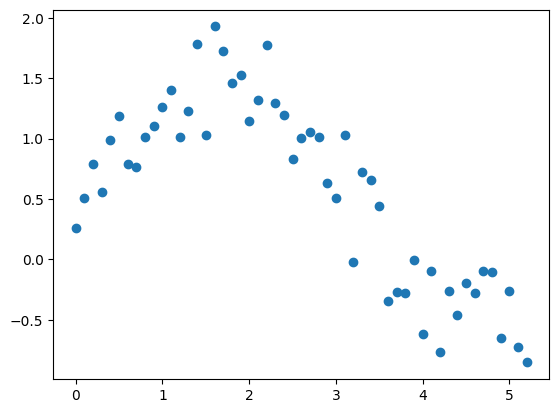

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("data_preg.csv", header=None, names=['x', 'y'])
x = data['x']
y = data['y']

plt.scatter(x, y) # b
plt.show()

In [73]:
from typing import Literal

y_predictions: dict[Literal['p1', 'p2', 'p3', 'p8'], np.ndarray] = {}
y_train_predictions: dict[Literal['p1', 'p2', 'p3', 'p8'], np.ndarray] = {}
y_test_predictions: dict[Literal['p1', 'p2', 'p3', 'p8'], np.ndarray] = {}

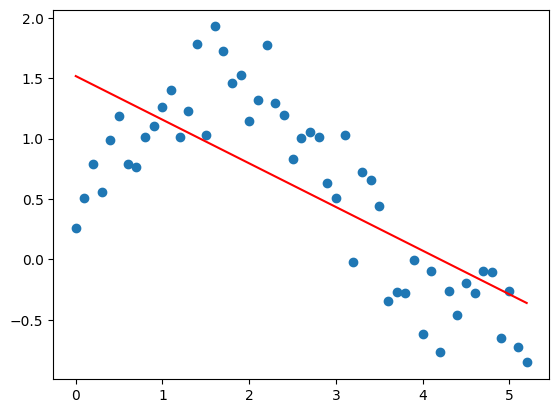

In [74]:
# c)
b1_poly1, b0_poly1 = np.polyfit(x, y, 1)
predict_linear = np.poly1d([b1_poly1, b0_poly1])

y_predictions['p1'] = predict_linear(x)

plt.scatter(x, y)
plt.plot(x, y_predictions['p1'], 'r')
plt.show()

In [75]:
from copy import deepcopy

X = x.to_numpy()
y = y.to_numpy()

def polynomial_regression(X: np.ndarray, y: np.ndarray, deg: int) -> tuple[np.ndarray, np.ndarray]:
    X_poly = np.column_stack([X**i for i in range(deg + 1)])

    transposed_matrix = X_poly.T # X^t
    inverted_matrix = np.linalg.inv(transposed_matrix @ X_poly) # (X^t X)^(-1)
    beta = inverted_matrix @ transposed_matrix @ y # (X^t X)^(-1) * X^t * y

    def predict(X: np.ndarray) -> np.ndarray:
        return X @ beta

    return beta, predict(X_poly) # Retorna β e 𝑦̂

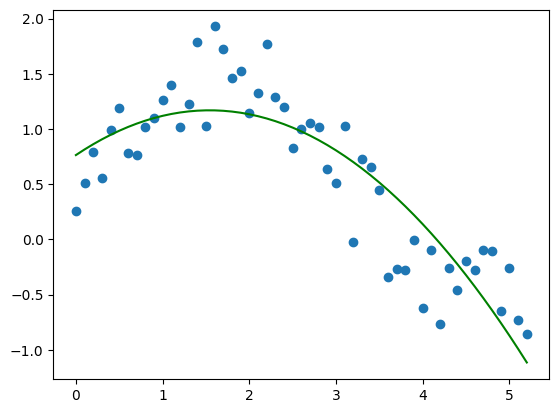

In [76]:
# d)
_, y_predictions['p2'] = polynomial_regression(X, y, 2)

plt.scatter(x, y)
plt.plot(x, y_predictions['p2'], 'g')
plt.show()

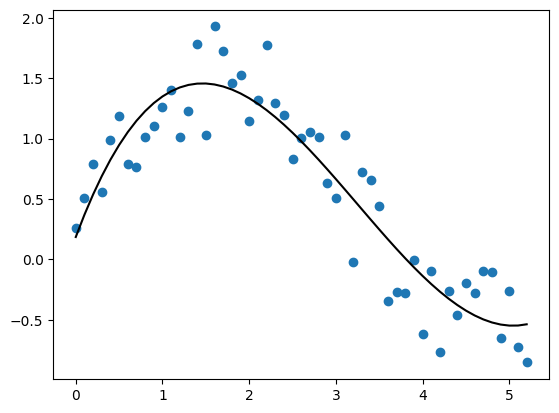

In [77]:
# e)
beta, y_predictions['p3'] = polynomial_regression(X, y, 3)

plt.scatter(x, y)
plt.plot(x, y_predictions['p3'], 'black')
plt.show()

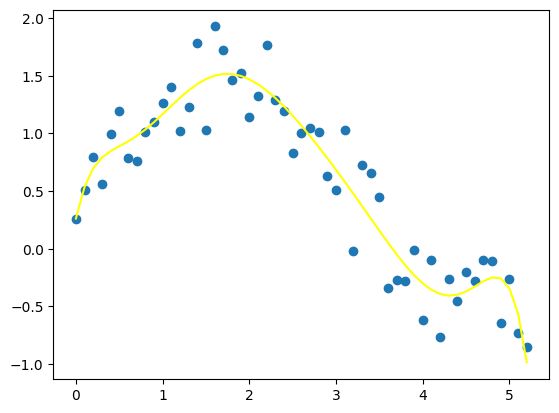

In [78]:
# f)
beta, y_predictions['p8'] = polynomial_regression(X, y, 8)

plt.scatter(x, y)
plt.plot(x, y_predictions['p8'], 'yellow')
plt.show()

In [79]:
def residual(y: float, y_hat: float) -> float:
    return (y - y_hat)**2

def residual_sum(y: np.ndarray, y_hat: np.ndarray) -> float:
    return np.sum([residual(y[i], y_hat[i]) for i in range(len(y))])

def eqm(y: np.ndarray, y_hat: np.ndarray) -> float:
    return 1 / len(y) * residual_sum(y, y_hat)

In [80]:
# g) Calcule o Erro Quadrático Médio (EQM) para cada linha de regressão.
# Qual é o mais preciso?
for key, value in y_predictions.items():
    print(f'EQM {key}:', eqm(y, value))

EQM p1: 0.2659342636924439
EQM p2: 0.1385264902757942
EQM p3: 0.07869725256060661
EQM p8: 0.05870934697421276


In [81]:
# h)
def split_train_test(x: np.ndarray, y: np.ndarray, proportion: float) -> tuple[np.ndarray, np.ndarray]:
    full_dataset = np.column_stack((x, y))

    # Aleatoriza os dados
    np.random.shuffle(full_dataset)
    train_size = int(len(full_dataset) * proportion)

    return full_dataset[:train_size], full_dataset[train_size:]

# Divide 90/10
training_set, test_set = split_train_test(x, y, 0.9)

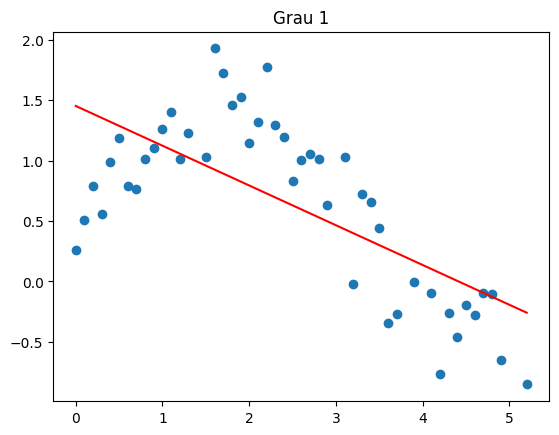

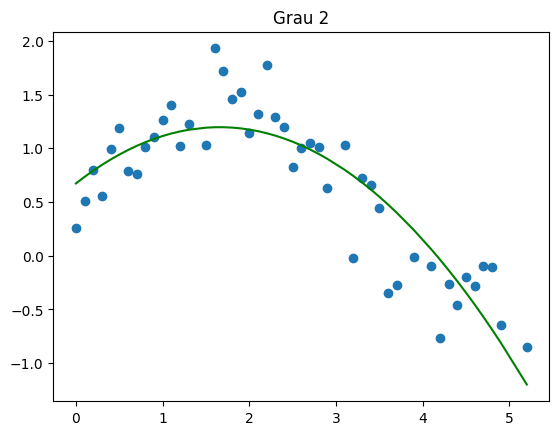

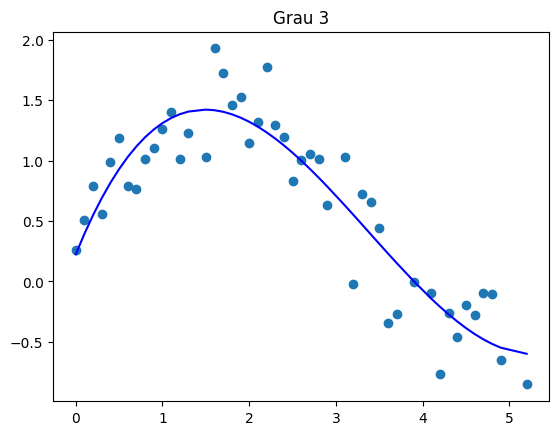

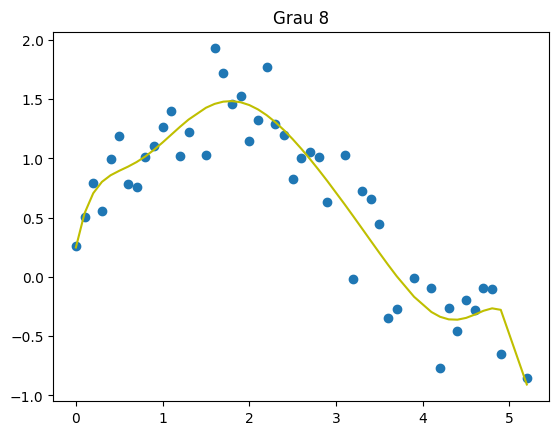

In [82]:
# i)
training_set_x = training_set[:, 0]
training_set_y = training_set[:, 1]

sorted_indexes = np.argsort(training_set_x)
x_sorted = training_set_x[sorted_indexes]

degrees = [1, 2, 3, 8]
colors = ['r', 'g', 'b', 'y']
y_train_predictions = {}

for i, degree in enumerate(degrees):
    key = f'p{degree}'

    _, y_train_predictions[key] = polynomial_regression(training_set_x, training_set_y, degree)

    y_sorted = y_train_predictions[key][sorted_indexes]

    plt.scatter(training_set_x, training_set_y)
    plt.plot(x_sorted, y_sorted, colors[i])
    plt.title(f'Grau {degree}')
    plt.show()

In [94]:
# j)
test_set_x = test_set[:, 0]
test_set_y = test_set[:, 1]

degrees = [1, 2, 3, 8]
y_test_predictions = {}

# Calculando as previsões dos dados de teste usando os pesos do treino
for degree in degrees:
    key = f'p{degree}'
    beta_train, _ = polynomial_regression(training_set_x, training_set_y, degree)

    X_test_poly = np.column_stack([test_set_x**i for i in range(degree + 1)])

    y_test_predictions[key] = X_test_poly @ beta_train # 𝑦̂ = X*𝛽

# Calculando o EQM do teste
for key, value in y_test_predictions.items():
    print(f'EQM {key}:', eqm(test_set_y, value))

EQM p1: 0.2819014978157123
EQM p2: 0.3331664268631651
EQM p3: 0.1194151020272002
EQM p8: 0.07139351528569007


In [93]:
# k) Veja o que calcula o Coeficiente de Determinação ou R quadrado
# em https://pt.khanacademy.org/math/ap-statistics/bivariate-data-ap/assessing-fit-least-squares-regression/a/r-squared-intuition

# Calcule o R2 para os dados de treino e teste (veja a função r2_score da
# biblioteca sklearn.metrics). O que se pode concluir com os resultados?

from sklearn.metrics import r2_score

print('Train')
for key, value in y_train_predictions.items():
    print(f'R2 {key}:', r2_score(training_set_y, value))

print('Test')
for key, value in y_test_predictions.items():
    print(f'R2 {key}:', r2_score(test_set_y, value))


Train
R2 p1: 0.4778594387680565
R2 p2: 0.7737737867201109
R2 p3: 0.8528106806931431
R2 p8: 0.8857111099450308

Test
R2 p1: 0.8552678306150016
R2 p2: 0.9377699094991813
R2 p3: 0.9618761283085135
R2 p8: 0.9343922600404567


 l) Visto o cálculo do erro e do coeficiente de determinação, qual o modelo mais preciso neste caso? Explique sua resposta.

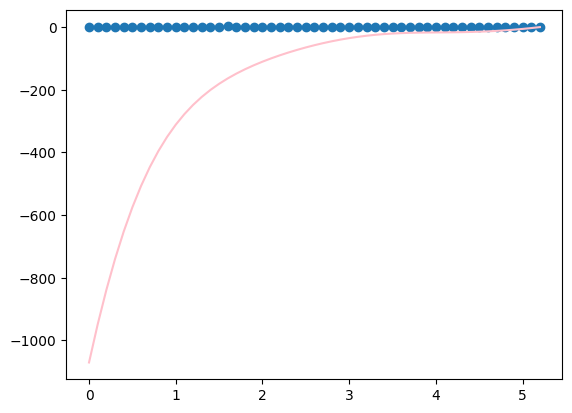

In [86]:
# m) Trace a curva de regressão polinomial de grau 20 no gráfico de dispersão
# dos dados. Compare o comportamento desta curva com os modelos de grau 1, 2, 3
# e 8 e analise o erro quadrático médio (EQM) nos dados de treinamento e nos
# dados de teste. O modelo de grau 20 apresenta melhor desempenho nos dados de
# teste? O que acontece com a forma da curva? Justifique sua resposta.
beta, y_poly20 = polynomial_regression(X, y, 20)

plt.scatter(x, y)
plt.plot(x, y_poly20, 'pink')
plt.show()